In [18]:
import torch
import torch.nn as nn
import math
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'使用デバイス: {device}')

使用デバイス: cuda


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f'データ数: {len(dataset)}')
x, y = next(iter(dataloader))
print(f'バッチのshape: {x.shape}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

データ数: 60000
バッチのshape: torch.Size([64, 1, 28, 28])


In [8]:
import torch

class DDPM:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T = T
        self.device = device

        # β_t のスケジュール（線形）
        self.beta = torch.linspace(beta_start, beta_end, T).to(device)
        self.alpha = 1 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)  # ᾱ_t

    def add_noise(self, x0, t):
        """
        任意のステップ t に一括でノイズを加える（閉形式）
        q(x_t | x_0) = N(x_t; √ᾱ_t · x_0, (1-ᾱ_t)·I)
        """
        noise = torch.randn_like(x0)
        a_bar = self.alpha_bar[t].view(-1, 1, 1, 1)
        x_t = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
        return x_t, noise

    @torch.no_grad()
    def sample_step(self, model, x_t, t):
        """逆方向1ステップ: ノイズを少し除去する"""
        t_tensor = torch.tensor([t], device=self.device)
        predicted_noise = model(x_t, t_tensor)

        beta = self.beta[t]
        alpha = self.alpha[t]
        a_bar = self.alpha_bar[t]

        mean = (1 / torch.sqrt(alpha)) * (
            x_t - (beta / torch.sqrt(1 - a_bar)) * predicted_noise
        )
        if t == 0:
            return mean
        noise = torch.randn_like(x_t)
        return mean + torch.sqrt(beta) * noise

In [12]:
import torch
import torch.nn as nn
import math

class SinusoidalEmbedding(nn.Module):
    """時刻 t をベクトルに変換（Transformerと同じ仕組み）"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / half
        )
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, time_dim=64):
        super().__init__()
        self.time_embed = SinusoidalEmbedding(time_dim)

        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(in_channels, 32, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU())

        # Bottleneck（時刻情報を注入）
        self.time_proj = nn.Linear(time_dim, 64)
        self.bottleneck = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())

        # Decoder
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU())
        self.dec2 = nn.Conv2d(64, in_channels, 3, padding=1)  # skipあり

    def forward(self, x, t):
        t_emb = self.time_embed(t)           # 時刻埋め込み
        t_emb = self.time_proj(t_emb).view(-1, 64, 1, 1)

        e1 = self.enc1(x)                    # skip connection用
        e2 = self.enc2(e1)
        b  = self.bottleneck(e2 + t_emb)    # 時刻を足し込む
        d1 = self.dec1(b)
        return self.dec2(torch.cat([d1, e1], dim=1))  # skip connection

In [13]:
ddpm  = DDPM(device=device)
model = SimpleUNet().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=2e-4)

for epoch in range(50):
    for x0, _ in dataloader:
        x0 = x0.to(device)
        t  = torch.randint(0, ddpm.T, (x0.shape[0],), device=device)
        x_t, noise = ddpm.add_noise(x0, t)
        loss = ((model(x_t, t) - noise) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    print(f'Epoch {epoch+1}/50  loss={loss.item():.4f}')

Epoch 1/50  loss=0.0765
Epoch 2/50  loss=0.0433
Epoch 3/50  loss=0.0490
Epoch 4/50  loss=0.0406
Epoch 5/50  loss=0.0489
Epoch 6/50  loss=0.0419
Epoch 7/50  loss=0.0336
Epoch 8/50  loss=0.0329
Epoch 9/50  loss=0.0327
Epoch 10/50  loss=0.0418
Epoch 11/50  loss=0.0404
Epoch 12/50  loss=0.0308
Epoch 13/50  loss=0.0442
Epoch 14/50  loss=0.0289
Epoch 15/50  loss=0.0405
Epoch 16/50  loss=0.0261
Epoch 17/50  loss=0.0224
Epoch 18/50  loss=0.0487
Epoch 19/50  loss=0.0406
Epoch 20/50  loss=0.0338
Epoch 21/50  loss=0.0327
Epoch 22/50  loss=0.0376
Epoch 23/50  loss=0.0340
Epoch 24/50  loss=0.0411
Epoch 25/50  loss=0.0345
Epoch 26/50  loss=0.0361
Epoch 27/50  loss=0.0343
Epoch 28/50  loss=0.0329
Epoch 29/50  loss=0.0293
Epoch 30/50  loss=0.0375
Epoch 31/50  loss=0.0376
Epoch 32/50  loss=0.0196
Epoch 33/50  loss=0.0265
Epoch 34/50  loss=0.0291
Epoch 35/50  loss=0.0296
Epoch 36/50  loss=0.0234
Epoch 37/50  loss=0.0305
Epoch 38/50  loss=0.0313
Epoch 39/50  loss=0.0319
Epoch 40/50  loss=0.0230
Epoch 41/

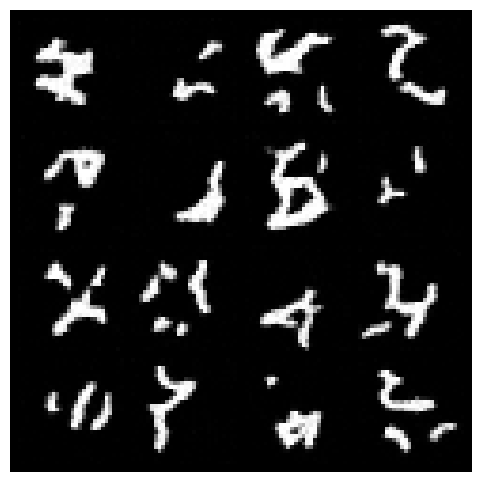

In [19]:
import torchvision

model.eval()
x = torch.randn(16, 1, 28, 28).to(device)

for t in reversed(range(ddpm.T)):
    x = ddpm.sample_step(model, x, t)

# 表示
grid = torchvision.utils.make_grid((x + 1) / 2, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.cpu().permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [16]:
torchvision.utils.save_image((x + 1) / 2, 'sample.png', nrow=4)
print('sample.png に保存しました')

sample.png に保存しました
